# 📚 Notebook 05: RAG — Multimodal FAISS Retrieval

**Objective:** Build a FAISS vector store from training embeddings, then evaluate retrieval quality.

**Sections:**
1. Build FAISS index over training set
2. Save index to disk
3. Load index + run retrieval queries
4. Visualize retrieved results
5. Compute MAP@K, Recall@K, NDCG@K metrics

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from transformers import AutoTokenizer
import torchvision.transforms as T

import config
from src.training.multimodal_predictor import MultimodalClinicalPredictor, MultimodalDataset
from src.retrieval.faiss_retrieval import MultimodalFAISSRetriever

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

val_transform = T.Compose([
    T.Resize(config.IMAGE_SIZE), T.ToTensor(),
    T.Normalize(mean=config.IMG_MEAN, std=config.IMG_STD),
])

Device: cuda


## 1️⃣ Load Model + Training Data

In [2]:
hf_token  = config.HF_TOKEN if config.HF_TOKEN != 'YOUR_HF_TOKEN_HERE' else None
tokenizer = AutoTokenizer.from_pretrained(config.TEXT_ENCODER_MODEL, token=hf_token)

model = MultimodalClinicalPredictor(
    num_classes=config.NUM_CLASSES,
    text_model_name=config.TEXT_ENCODER_MODEL,
    hidden_dim=config.FUSION_HIDDEN_DIM,
    dropout_rate=0.0,
).to(DEVICE).eval()

if config.BEST_MODEL_PATH.exists():
    model.load_state_dict(torch.load(config.BEST_MODEL_PATH, map_location=DEVICE))
    print('✅ Loaded trained model checkpoint')
else:
    print('⚠️  No checkpoint — using pretrained embeddings for FAISS demo')

df_train = pd.read_csv('../data/processed/train.csv')
df_test  = pd.read_csv('../data/processed/test.csv')

train_ds = MultimodalDataset(df_train, val_transform, tokenizer, config.MAX_TEXT_LENGTH)
train_loader_faiss = torch.utils.data.DataLoader(train_ds, batch_size=16, shuffle=False, num_workers=0)

# Metadata for FAISS index
metadata_list = [{
    'image_id':   row['image_id'],
    'label':      int(row['label']),
    'label_name': row['label_name'],
    'text':       str(row['text'])[:200],  # Truncated text snippet
    'modality':   row.get('modality', 'Unknown'),
} for _, row in df_train.iterrows()]

print(f'Training set: {len(df_train)} samples')
print(f'Will index up to {config.FAISS_MAX_RECORDS} records')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Loaded trained model checkpoint
Training set: 1433 samples
Will index up to 500 records


## 2️⃣ Build & Save FAISS Index

In [3]:
retriever = MultimodalFAISSRetriever(embedding_dim=1792)  # 1024 (image) + 768 (text)

retriever.build_index(
    model=model,
    dataloader=train_loader_faiss,
    metadata_list=metadata_list,
    device=DEVICE,
    max_records=config.FAISS_MAX_RECORDS,
)

retriever.save(
    index_path=str(config.FAISS_INDEX_PATH),
    meta_path=str(config.FAISS_META_PATH),
)

print(f'\n✅ FAISS index built and saved:')
print(f'   Index: {config.FAISS_INDEX_PATH}')
print(f'   Meta:  {config.FAISS_META_PATH}')
print(f'   Total vectors indexed: {retriever.index.ntotal}')

Encoding for FAISS:  36%|███▌      | 32/90 [00:42<01:16,  1.32s/it]


✅ FAISS index built and saved:
   Index: Z:\study files\SRM_study\SEM-2\AML-509_Agentic AI and GAN\Team Project\Agent_code_Trial-2\Trial_2\data\faiss_index.bin
   Meta:  Z:\study files\SRM_study\SEM-2\AML-509_Agentic AI and GAN\Team Project\Agent_code_Trial-2\Trial_2\data\faiss_meta.pkl
   Total vectors indexed: 500


## 3️⃣ Retrieval Demo — Test Queries

In [4]:
# Load index from disk (mimics production use)
retriever2 = MultimodalFAISSRetriever(embedding_dim=1792)
retriever2.load(
    index_path=str(config.FAISS_INDEX_PATH),
    meta_path=str(config.FAISS_META_PATH),
)
print(f'Index loaded: {retriever2.index.ntotal} vectors')

# Run retrieval on 3 test samples
test_samples = df_test.sample(3, random_state=42).reset_index(drop=True)

for i, row in test_samples.iterrows():
    img_pil = Image.open(row['image_path']).convert('RGB')
    img_t   = val_transform(img_pil).unsqueeze(0).to(DEVICE)
    enc = tokenizer(str(row['text']), max_length=config.MAX_TEXT_LENGTH,
                    padding='max_length', truncation=True, return_tensors='pt')

    results = retriever2.retrieve(
        model, img_t, enc['input_ids'].to(DEVICE), enc['attention_mask'].to(DEVICE),
        top_k=config.FAISS_TOP_K, device=DEVICE
    )[0]

    print(f'\n=== Query {i+1}: {row["image_id"]} | True: {row["label_name"]} ===')
    for res in results:
        match = '✅' if res['label'] == row['label'] else '❌'
        print(f'  Rank {res["rank"]} | Sim: {res["similarity"]:.4f} | {match} {res["label_name"]} | {res["image_id"]}')

Index loaded: 500 vectors

=== Query 1: MPX2218_synpic30800 | True: Clinical Sign/Other ===
  Rank 1 | Sim: 0.7382 | ❌ Trauma | MPX2097_synpic19228
  Rank 2 | Sim: 0.7346 | ❌ Neoplasm | MPX2507_synpic50874
  Rank 3 | Sim: 0.7220 | ✅ Clinical Sign/Other | MPX2218_synpic30796
  Rank 4 | Sim: 0.7166 | ❌ Neoplasm | MPX1935_synpic34505
  Rank 5 | Sim: 0.7112 | ❌ Neoplasm | MPX1214_synpic1100

=== Query 2: MPX2441_synpic24606 | True: Congenital ===
  Rank 1 | Sim: 0.8107 | ❌ Idiopathic/Unknown | MPX2483_synpic27405
  Rank 2 | Sim: 0.8039 | ❌ Vascular | MPX2347_synpic39718
  Rank 3 | Sim: 0.7896 | ❌ Vascular | MPX1672_synpic24428
  Rank 4 | Sim: 0.7737 | ✅ Congenital | MPX1467_synpic21882
  Rank 5 | Sim: 0.7723 | ❌ Clinical Sign/Other | MPX1838_synpic19187

=== Query 3: MPX1058_synpic17148 | True: Vascular ===
  Rank 1 | Sim: 0.8162 | ❌ Clinical Sign/Other | MPX1755_synpic17667
  Rank 2 | Sim: 0.7930 | ❌ Infection | MPX2479_synpic24745
  Rank 3 | Sim: 0.7908 | ❌ Neoplasm | MPX2584_synpic19855

## 4️⃣ Retrieval Metrics — MAP@K, Recall@K, NDCG@K

In [5]:
from tqdm.auto import tqdm

# Evaluate on full test set (or first 100 for speed)
eval_df = df_test.head(100)

query_labels    = []
all_retrieved   = []

print('Running retrieval evaluation on test set...')
for _, row in tqdm(eval_df.iterrows(), total=len(eval_df)):
    img_pil = Image.open(row['image_path']).convert('RGB')
    img_t   = val_transform(img_pil).unsqueeze(0).to(DEVICE)
    enc = tokenizer(str(row['text']), max_length=config.MAX_TEXT_LENGTH,
                    padding='max_length', truncation=True, return_tensors='pt')

    results = retriever2.retrieve(
        model, img_t, enc['input_ids'].to(DEVICE), enc['attention_mask'].to(DEVICE),
        top_k=5, device=DEVICE
    )[0]

    query_labels.append(int(row['label']))
    all_retrieved.append(results)

# Compute metrics
metrics = retriever2.retrieve_metrics(
    query_labels=query_labels,
    retrieved_results=all_retrieved,
    k_values=[1, 3, 5],
)

print('\n=== RETRIEVAL EVALUATION METRICS ===')
print(f'{"Metric":<15} {"Value"}')
print('-' * 30)
for k, v in metrics.items():
    print(f'{k:<15} {v:.4f}')

Running retrieval evaluation on test set...


  0%|          | 0/100 [00:00<?, ?it/s]


=== RETRIEVAL EVALUATION METRICS ===
Metric          Value
------------------------------
MAP@1           0.4200
R@1             0.4200
NDCG@1          0.4200
MAP@3           0.4892
R@3             0.5900
NDCG@3          0.7004
MAP@5           0.5060
R@5             0.7200
NDCG@5          0.8720


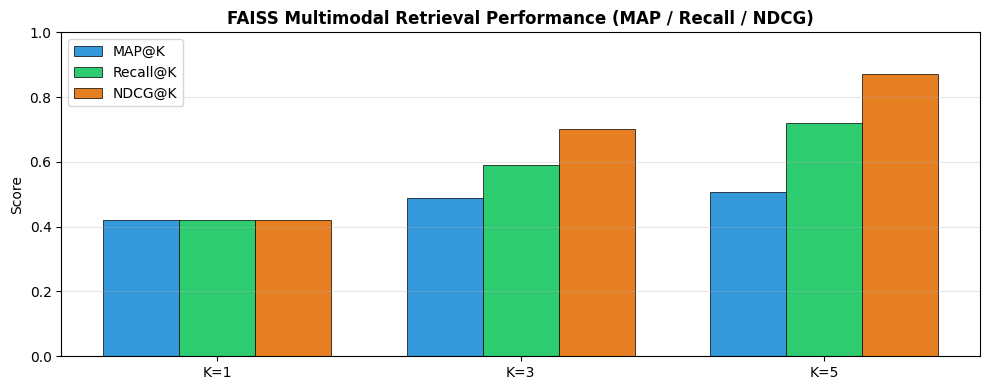


✅ RAG retrieval complete. Proceed to Notebook 06: Multi-Agent Synthesis.


In [6]:
# Bar chart of retrieval metrics
fig, ax = plt.subplots(figsize=(10, 4))

groups = ['K=1', 'K=3', 'K=5']
x = np.arange(len(groups))
w = 0.25

ax.bar(x - w,   [metrics[f'MAP@{k}']  for k in [1,3,5]], w, label='MAP@K',   color='#3498DB', edgecolor='black', lw=0.5)
ax.bar(x,       [metrics[f'R@{k}']    for k in [1,3,5]], w, label='Recall@K', color='#2ECC71', edgecolor='black', lw=0.5)
ax.bar(x + w,   [metrics[f'NDCG@{k}'] for k in [1,3,5]], w, label='NDCG@K',  color='#E67E22', edgecolor='black', lw=0.5)

ax.set_xticks(x); ax.set_xticklabels(groups)
ax.set_ylabel('Score'); ax.set_ylim(0, 1)
ax.set_title('FAISS Multimodal Retrieval Performance (MAP / Recall / NDCG)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../outputs/retrieval_metrics.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n✅ RAG retrieval complete. Proceed to Notebook 06: Multi-Agent Synthesis.')